# BrushCue Example: Tint Toward Color

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/tint_toward_color.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/tint-toward-color

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


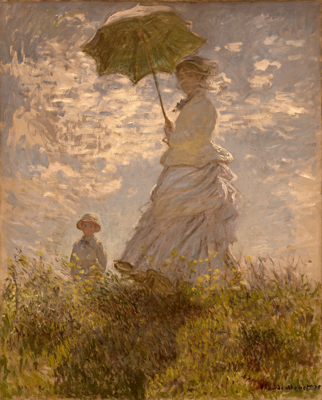

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
tint_color = bc.ProfiledColor.from_srgb_hex("#C97B2D")
strength = 0.5
graph = input_image.color_transformer_shader(
    "return vec4<f32>(input.r, mix(input.g, tint_color.g, strength), mix(input.b, tint_color.b, strength), input.a);",
    "",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create().add("tint_color", tint_color).add("strength", strength),
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
